In [ ]:
import os
import json
import pandas as pd
import numpy as np
import glob
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [6]:
def process_rehab_json(file_paths):
    dataset_rows = []
    
    for file_path in file_paths:
        with open(file_path, 'r', encoding='utf-8') as f:
            # Assumiamo che il file contenga una lista di documenti
            docs = json.load(f) 
            
            for doc in docs:
                # Estraiamo la data di pianificazione (serve per calcolare l'età)
                planning_date_str = doc.get('planningDate', {}).get('$date')
                if not planning_date_str:
                    continue
                planning_date = pd.to_datetime(planning_date_str).tz_localize(None)
                
                # Cicliamo solo sulle sedute nell'agenda
                for item in doc.get('agenda', []):
                    operator = item.get('operator', {})
                    patient = item.get('patient', {})
                    session = item.get('session', {})
                    
                    # Calcolo target: durata effettiva decisa dal solver
                    start_time = pd.to_datetime(item.get('start'), format='%H:%M', errors='coerce')
                    end_time = pd.to_datetime(item.get('end'), format='%H:%M', errors='coerce')
                    duration_target = (end_time - start_time).seconds / 60 if pd.notnull(start_time) and pd.notnull(end_time) else np.nan
                    
                    # Calcolo feature derivata: età del paziente
                    birth_date_str = patient.get('birthDate')
                    age = np.nan
                    if birth_date_str:
                        birth_date = pd.to_datetime(birth_date_str).tz_localize(None)
                        age = (planning_date - birth_date).days / 365.25
                        
                    # Costruiamo la riga
                    row = {
                        # Feature Paziente
                        'pat_type': patient.get('type'),
                        'pat_autonomous': patient.get('autonomous'),
                        'pat_aidNeeds': patient.get('aidNeeds'),
                        'pat_overallMinLength': patient.get('overallMinLength'),
                        'pat_age': age, # Feature derivata
                        'pat_has_preferred_ops': len(patient.get('preferredOps', [])) > 0, # Feature derivata
                        
                        # Feature Operatore
                        'op_jobKind': operator.get('jobKind'),
                        'op_burdenScore': operator.get('burdenScore'),
                        'op_qualifications_count': len(operator.get('qualifications', [])), # Derivata
                        
                        # Feature Sessione (Richiesta)
                        'sess_minLength': session.get('minLength'),
                        'sess_idealLength': session.get('idealLength'),
                        'sess_kind': session.get('kind'),
                        'sess_flexibility_delta': session.get('idealLength', 0) - session.get('minLength', 0), # Derivata
                        
                        # TARGET
                        'target_duration': duration_target
                    }
                    dataset_rows.append(row)
                    
    return pd.DataFrame(dataset_rows)

# Esecuzione: inserisci il path corretto dove hai salvato i JSON
json_files = glob.glob("data/*.json")
df = process_rehab_json(json_files)

# Per test, supponiamo che 'df' sia stato caricato
print(f"Estratte {len(df)} sedute.")

Estratte 10504 sedute.


In [7]:
def generate_statistical_report(df):
    report_data = []
    
    for col in df.columns:
        dtype = str(df[col].dtype)
        n_unique = df[col].nunique()
        n_missing = df[col].isnull().sum()
        pct_missing = (n_missing / len(df)) * 100
        
        # Analisi della distribuzione
        if pd.api.types.is_numeric_dtype(df[col]) and n_unique > 2:
            # Per le numeriche continue/discrete
            dist_info = f"Min: {df[col].min():.1f} | Media: {df[col].mean():.1f} | Max: {df[col].max():.1f}"
        else:
            # Per categoriche, booleane o numeriche con pochissimi valori
            top_vals = df[col].value_counts().head(3).to_dict()
            # Formattazione per renderlo leggibile
            dist_info = "Top val: " + ", ".join([f"{k} ({v})" for k, v in top_vals.items()])
            
        report_data.append({
            'Feature': col,
            'Tipo': dtype,
            'Valori Distinti': n_unique,
            'Valori Mancanti': f"{n_missing} ({pct_missing:.1f}%)",
            'Distribuzione': dist_info
        })
        
    report_df = pd.DataFrame(report_data)
    return report_df

# Esecuzione e visualizzazione
stats_report = generate_statistical_report(df)
display(stats_report)

,Feature,Tipo,Valori Distinti,Valori Mancanti,Distribuzione
0,pat_type,str,6,0 (0.0%),"Top val: O (4445), N (3057), MAC8 (2560)"
1,pat_autonomous,bool,1,0 (0.0%),Top val: False (10504)
2,pat_aidNeeds,str,2,0 (0.0%),"Top val: none (9923), lifter (581)"
3,pat_overallMinLength,int64,6,0 (0.0%),Min: 30.0 | Media: 61.3 | Max: 90.0
4,pat_age,float64,7808,0 (0.0%),Min: 11.1 | Media: 71.6 | Max: 99.2
5,pat_has_preferred_ops,bool,2,0 (0.0%),"Top val: True (10395), False (109)"
6,op_jobKind,str,3,0 (0.0%),"Top val: full-time (8587), part-time on mornings (1135), part-time on afternoons (782)"
7,op_burdenScore,int64,8,0 (0.0%),Min: 2.0 | Media: 4.0 | Max: 11.0
8,op_qualifications_count,int64,6,0 (0.0%),Min: 2.0 | Media: 4.8 | Max: 7.0
9,sess_minLength,int64,3,0 (0.0%),Min: 20.0 | Media: 35.6 | Max: 60.0


In [8]:
def drop_constant_features(df, stats_report):
    # Identifichiamo le colonne con un solo valore distinto
    constant_cols = stats_report[stats_report['Valori Distinti'] <= 1]['Feature'].tolist()
    
    if constant_cols:
        print(f"Rimosse {len(constant_cols)} feature costanti: {constant_cols}")
        df_cleaned = df.drop(columns=constant_cols)
    else:
        print("Nessuna feature costante trovata.")
        df_cleaned = df.copy()
        
    return df_cleaned

df_cleaned = drop_constant_features(df, stats_report)

Rimosse 1 feature costanti: ['pat_autonomous']


/var/folders/wg/0cp_65ts2slf57w15ldqqn9h0000gn/T/ipykernel_94099/4017451830.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


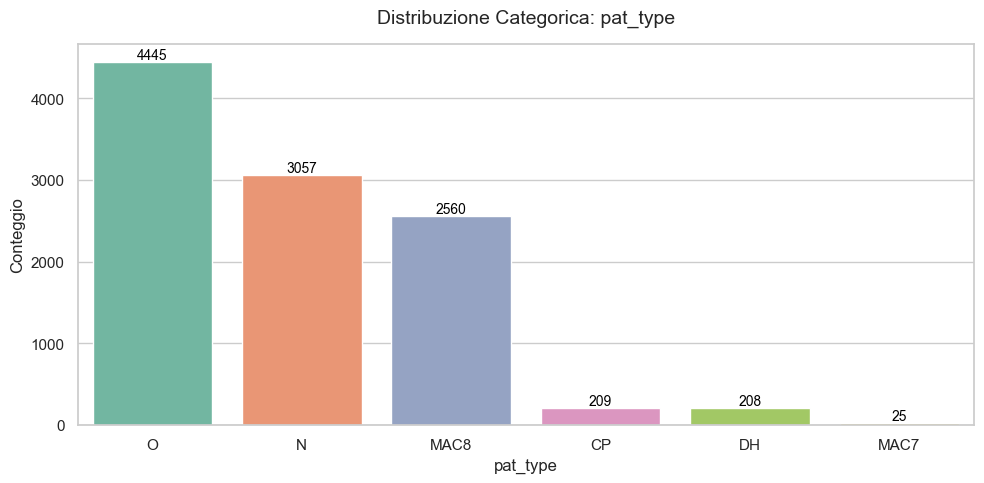

/var/folders/wg/0cp_65ts2slf57w15ldqqn9h0000gn/T/ipykernel_94099/4017451830.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


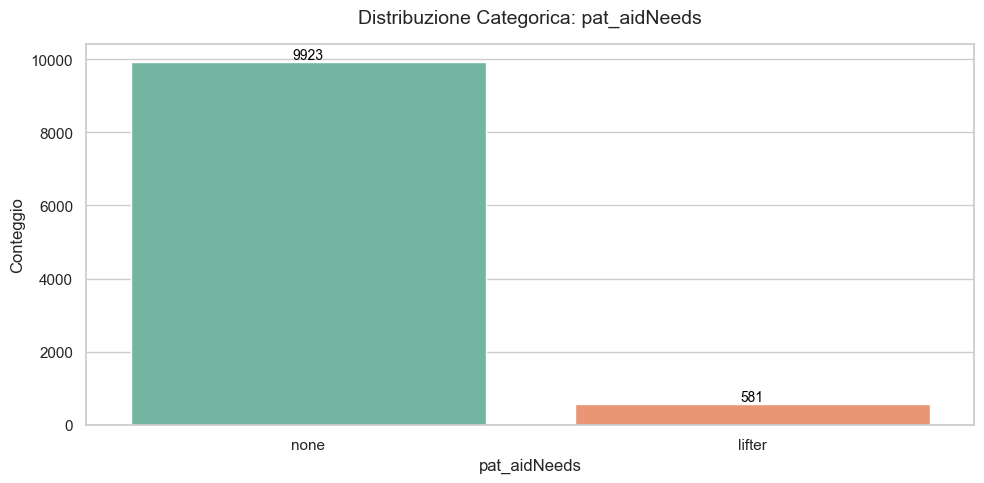

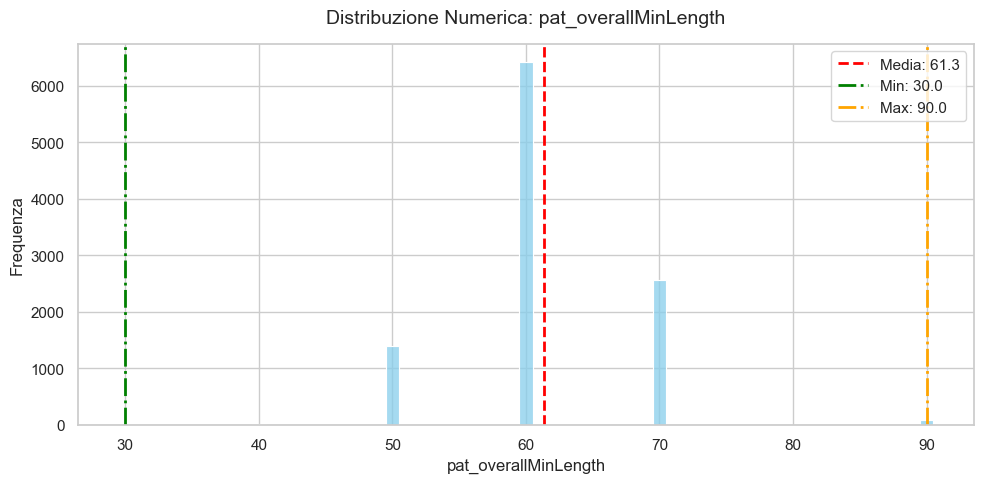

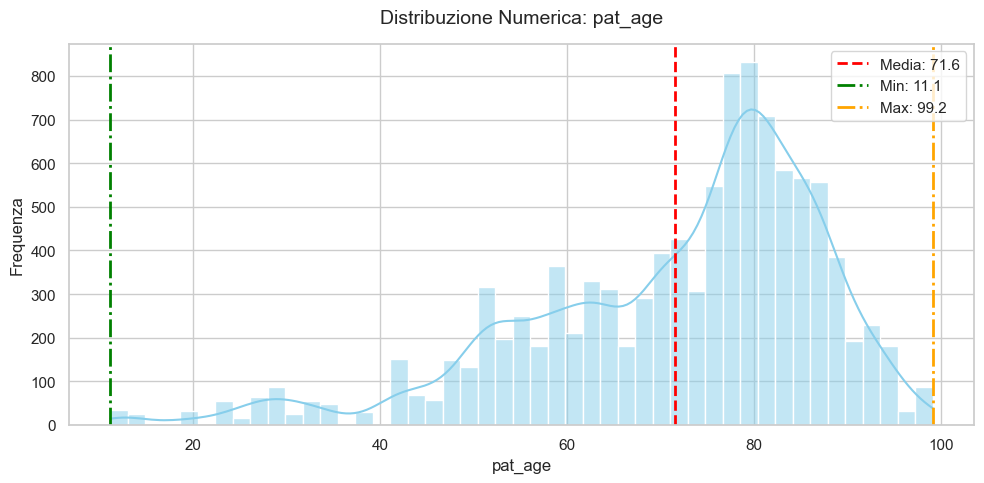

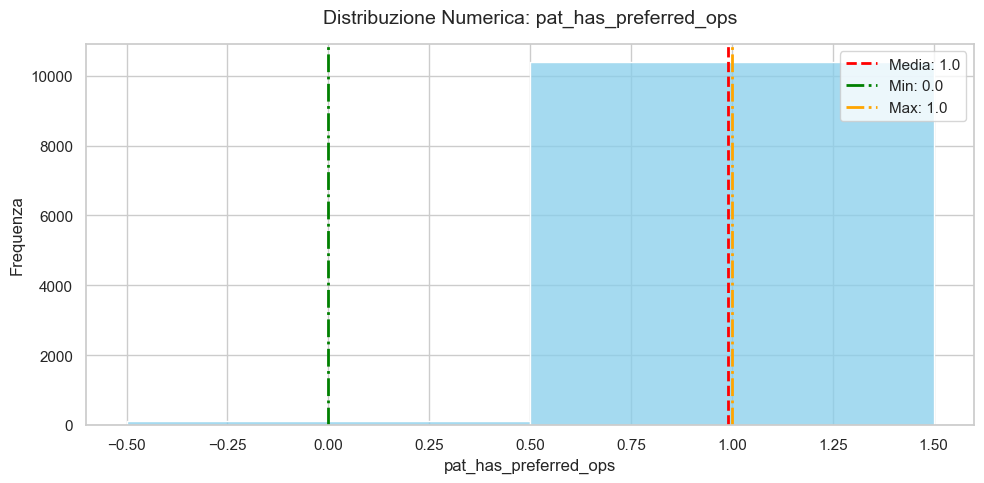

/var/folders/wg/0cp_65ts2slf57w15ldqqn9h0000gn/T/ipykernel_94099/4017451830.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


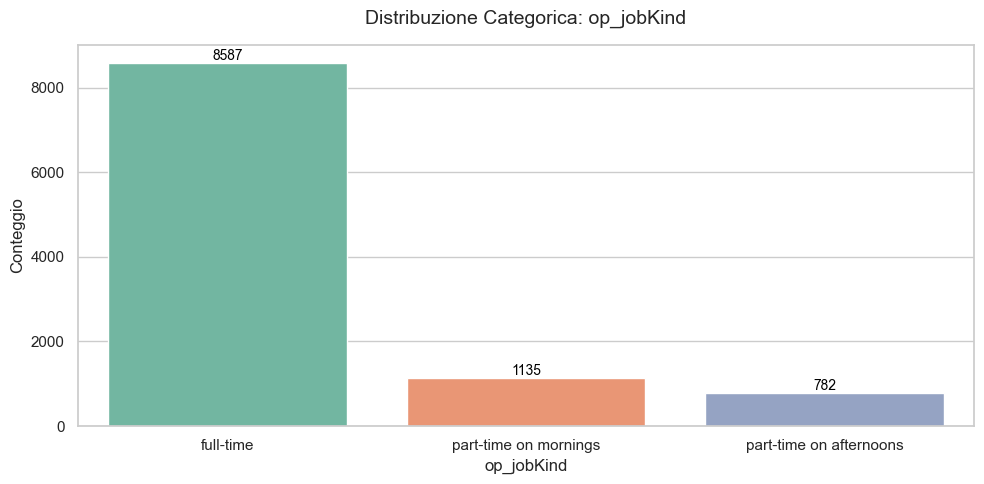

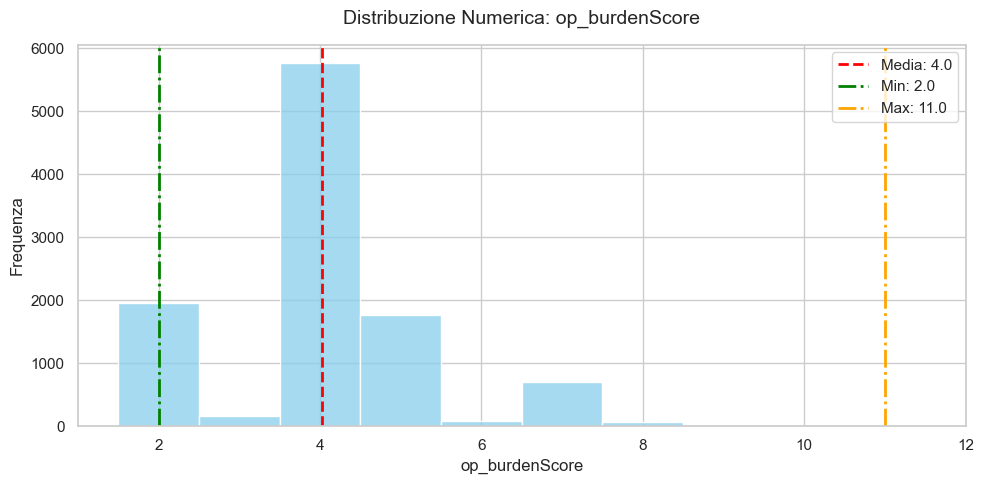

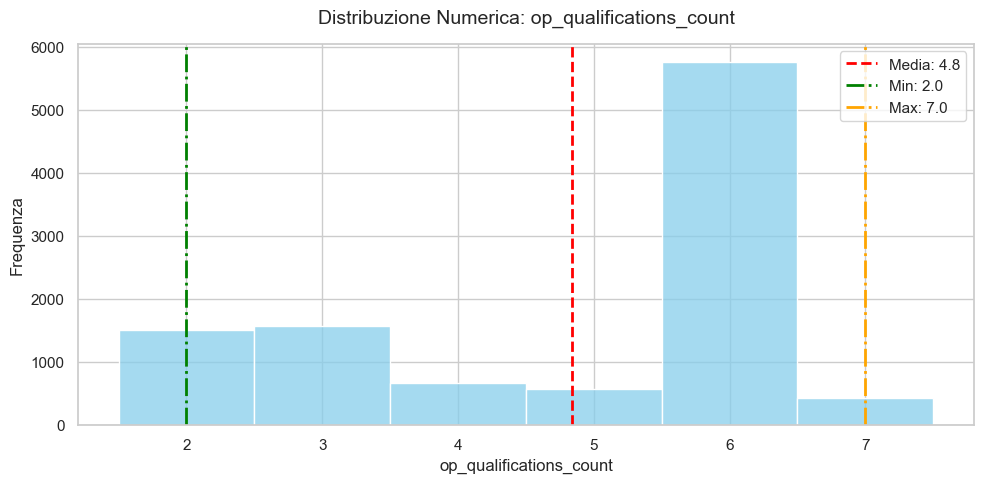

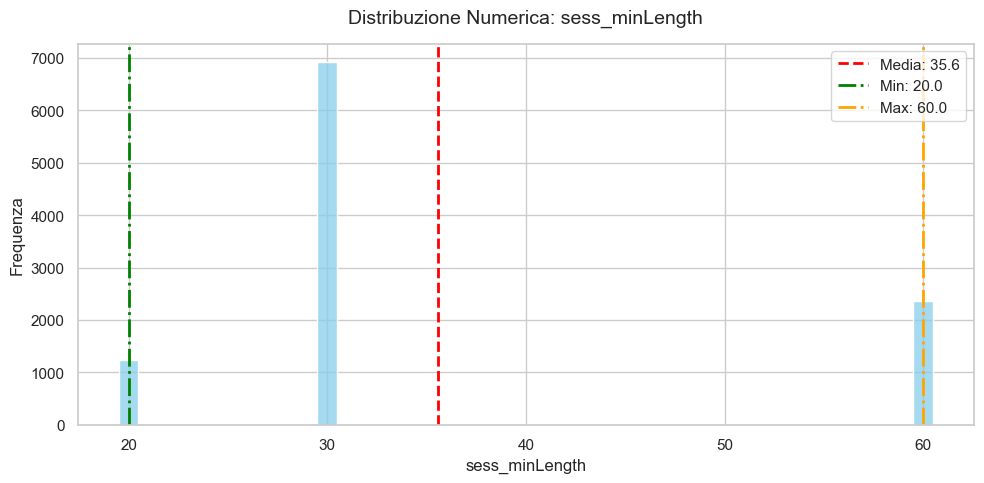

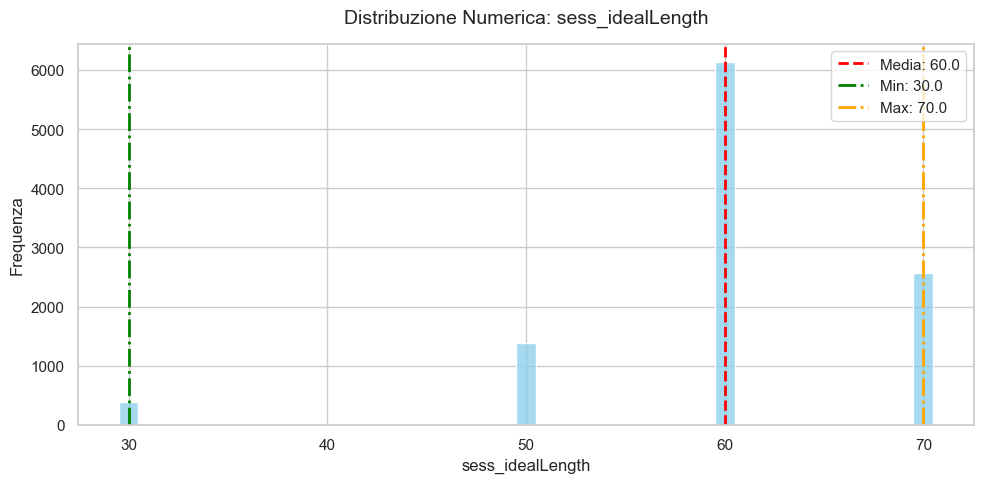

/var/folders/wg/0cp_65ts2slf57w15ldqqn9h0000gn/T/ipykernel_94099/4017451830.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


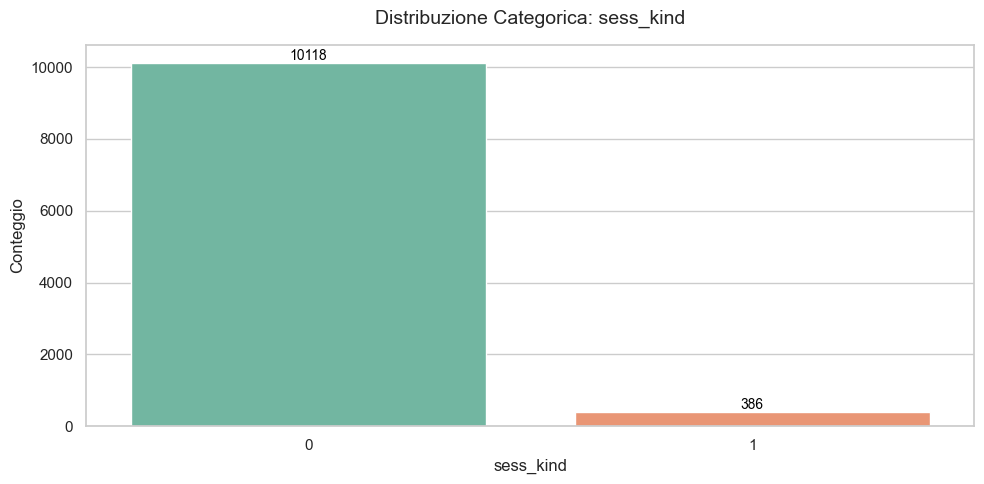

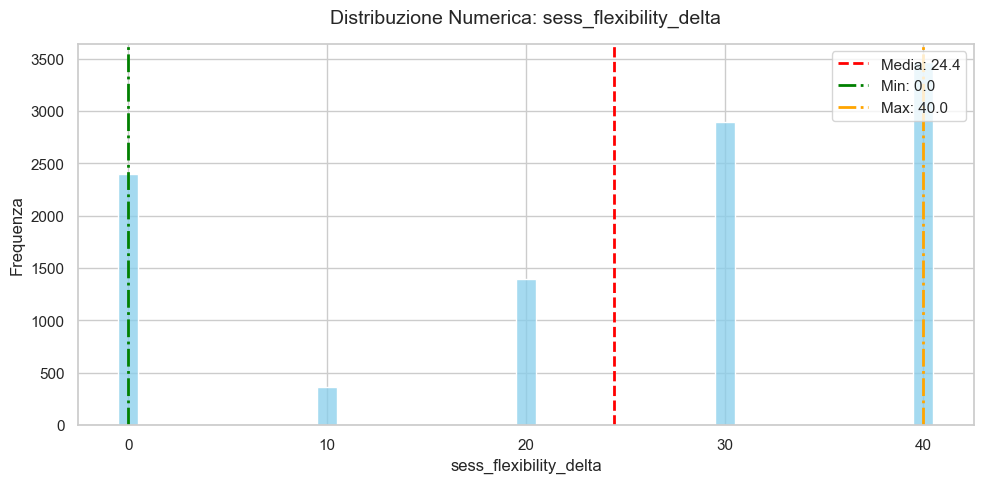

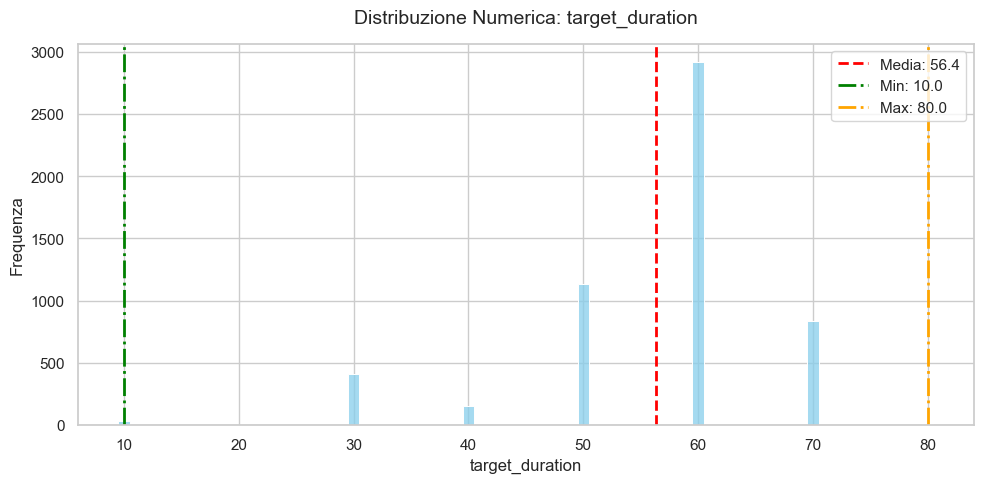

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(df):
    # Imposta lo stile visivo dei grafici
    sns.set_theme(style="whitegrid")
    
    # Cicliamo su tutte le colonne del dataset pulito
    for col in df.columns:
        plt.figure(figsize=(10, 5))
        
        # Se la colonna è numerica (float o int)
        if pd.api.types.is_numeric_dtype(df[col]):
            # Ignoriamo i NaN per il calcolo delle statistiche (es. target_duration)
            col_data = df[col].dropna()
            
            if len(col_data) == 0:
                continue
                
            min_val = col_data.min()
            max_val = col_data.max()
            mean_val = col_data.mean()
            
            # Se ci sono pochi valori unici, lo trattiamo come variabile discreta
            is_discrete = df[col].nunique() < 20
            
            # Creazione dell'istogramma
            sns.histplot(col_data, kde=not is_discrete, discrete=is_discrete, color="skyblue")
            
            # Aggiunta delle linee per Media, Min e Max
            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.1f}')
            plt.axvline(min_val, color='green', linestyle='-.', linewidth=2, label=f'Min: {min_val:.1f}')
            plt.axvline(max_val, color='orange', linestyle='-.', linewidth=2, label=f'Max: {max_val:.1f}')
            
            plt.title(f'Distribuzione Numerica: {col}', fontsize=14, pad=15)
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Frequenza', fontsize=12)
            plt.legend(loc='upper right')
            
        # Se la colonna è categorica, stringa o booleana
        else:
            # Creazione del grafico a barre ordinato per frequenza
            ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
            
            plt.title(f'Distribuzione Categorica: {col}', fontsize=14, pad=15)
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Conteggio', fontsize=12)
            
            # Aggiunta del numero esatto (conteggio) sopra ogni barra
            for p in ax.patches:
                count = int(p.get_height())
                if count > 0:
                    ax.annotate(f'{count}', 
                                (p.get_x() + p.get_width() / 2., p.get_height()), 
                                ha='center', va='center', fontsize=10, color='black', 
                                xytext=(0, 5), textcoords='offset points')
                    
        plt.tight_layout()
        
        # Salva le immagini nella cartella report (opzionale, decommenta la riga sotto se vuoi salvarle)
        # plt.savefig(f"report/dist_{col}.png")
        
        plt.show()

# Esecuzione della funzione sul dataset pulito
# Assicurati di avere seaborn installato (!pip install seaborn)
plot_feature_distributions(df_cleaned)

In [11]:
stats_report.to_csv("report/report.csv")

df_cleaned.to_csv("report/dataset.csv", index=False)